<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/formicacid_calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Acid partitioning in water, oil, and gas with NeqSim

This notebook preserves the original formic-acid and acetic-acid flash calculations and
extends them into a reproducible screening workflow for produced-fluid separation.

## Audience, prerequisites, and learning objectives

This tutorial is for process, production, and corrosion engineers who know basic phase
equilibrium. Python familiarity is helpful; no local files or proprietary data are required.

After completing it, you can:

1. build CPA fluids containing methane, water, and a carboxylic acid;
2. run equilibrium flashes and retrieve phase-specific acid mass rates;
3. compare formic and acetic acid without reusing hidden thermodynamic state;
4. quantify temperature and water-rate sensitivity;
5. compose a `Stream`, `ThreePhaseSeparator`, and `ProcessSystem`;
6. audit total and acid-component balances; and
7. state where an equilibrium screening model is—and is not—applicable.

In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

import neqsim

NEQSIM_VERSION = importlib.metadata.version("neqsim")

print(f"NeqSim package version: {NEQSIM_VERSION}")
print(f"Python version: {sys.version.split()[0]}")

NeqSim package version: 3.16.0
Python version: 3.12.13


## Engineering context and units

Low-molecular-weight organic acids can move between produced gas, hydrocarbon liquid, and
water. Their phase distribution affects sampling, aqueous corrosion screening, water
treatment, and separator routing. This notebook uses mass flow in kg/h, temperature in
°C, and absolute pressure in bara.

The examples are equilibrium screens. They do not model ionization, pH, corrosion rate,
reaction kinetics, adsorption, salts, solids, emulsions, or residence-time limitations.

In [2]:
import json
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid

plt.rcParams.update(
    {
        "figure.figsize": (8.0, 4.8),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True,
    check=False,
).stderr.splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java", "Platform"],
        "Version": [
            NEQSIM_VERSION,
            platform.python_version(),
            java_version,
            platform.platform(),
        ],
    }
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"
3,Platform,Linux-6.12.13-x86_64-with-glibc2.39


## Thermodynamic basis and model choice

At fixed temperature $T$ and pressure $P$, a flash calculation enforces equal component
fugacity in every equilibrium phase:

$$
f_i^{\alpha}(T,P,\mathbf{x}^{\alpha})
=
f_i^{\beta}(T,P,\mathbf{x}^{\beta})
$$

Here, $i$ is a component and $\alpha$ and $\beta$ identify phases. CPA
(Cubic-Plus-Association) combines a cubic equation of state with an association term, so
it is more appropriate than a non-associating cubic model for water and hydrogen-bonding
acids. Mixing rule 10 is retained from both original examples because it activates the
CPA aqueous-system parameterization used by NeqSim for this screen.

In [3]:
BASE_TEMPERATURE_C = 70.0
BASE_PRESSURE_BARA = 25.0
METHANE_RATE_KG_H = 1.0
ACID_RATE_KG_H = 0.1
WATER_RATE_KG_H = 100.0

base_inputs = pd.Series(
    {
        "Temperature [°C]": BASE_TEMPERATURE_C,
        "Pressure [bara]": BASE_PRESSURE_BARA,
        "Methane [kg/h]": METHANE_RATE_KG_H,
        "Acid [kg/h]": ACID_RATE_KG_H,
        "Water [kg/h]": WATER_RATE_KG_H,
    },
    name="Base water–gas flash",
)
display(base_inputs.to_frame())

,Base water–gas flash
Temperature [°C],70.0
Pressure [bara],25.0
Methane [kg/h],1.0
Acid [kg/h],0.1
Water [kg/h],100.0


## Solver and object workflow

NeqSim stores components, the CPA model, mixing rule, and state in one thermodynamic
system. `TPflash` solves the equilibrium state. We then retrieve each phase and convert
phase mole fraction to acid mass fraction before calculating the phase acid mass rate.
Every scenario below builds a fresh system to avoid state leakage.

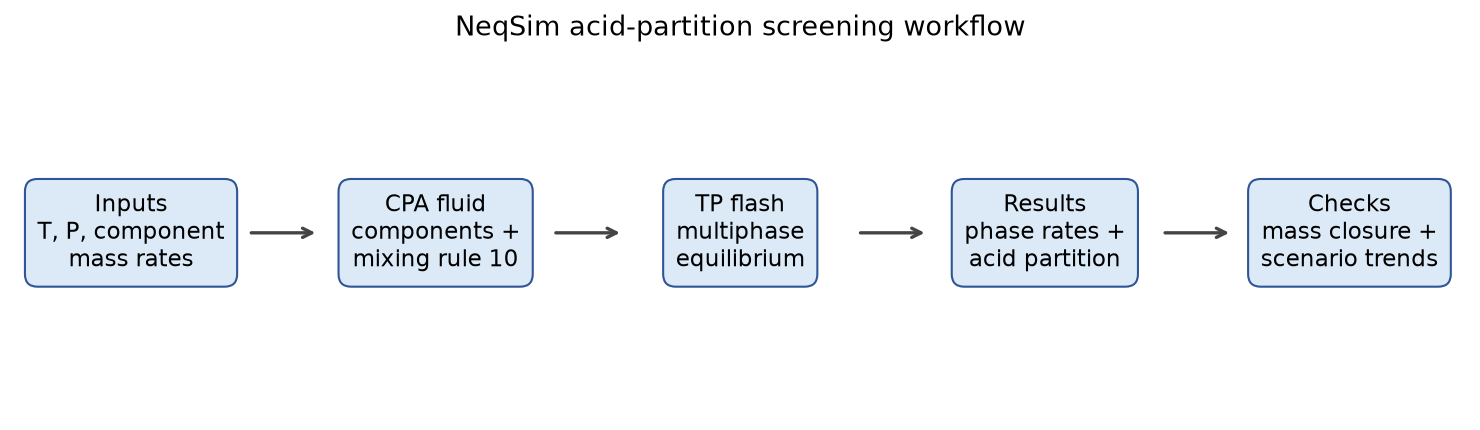

In [4]:
fig, axis = plt.subplots(figsize=(10.0, 3.0))
axis.axis("off")

steps = [
    ("Inputs", "T, P, component\nmass rates"),
    ("CPA fluid", "components +\nmixing rule 10"),
    ("TP flash", "multiphase\nequilibrium"),
    ("Results", "phase rates +\nacid partition"),
    ("Checks", "mass closure +\nscenario trends"),
]

positions = np.linspace(0.08, 0.92, len(steps))
for index, ((title, subtitle), x_position) in enumerate(zip(steps, positions)):
    axis.text(
        x_position,
        0.52,
        f"{title}\n{subtitle}",
        ha="center",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": "#DCEAF7",
            "edgecolor": "#2F5597",
        },
    )
    if index < len(steps) - 1:
        axis.annotate(
            "",
            xy=(positions[index + 1] - 0.08, 0.52),
            xytext=(x_position + 0.08, 0.52),
            arrowprops={"arrowstyle": "->", "color": "#444444", "lw": 1.6},
        )

axis.set_title("NeqSim acid-partition screening workflow", pad=14)
plt.tight_layout()
plt.show()

## Reusable two-phase flash helper

For a phase $k$, the acid mass fraction $w_{i,k}$ is calculated from mole fraction
$x_{i,k}$ and molar masses:

$$
w_{i,k}
=
\frac{x_{i,k} M_i}{M_k}
$$

The acid mass rate in that phase is $\dot m_{i,k}=w_{i,k}\dot m_k$. This conversion
avoids treating mole fraction as mass fraction.

In [5]:
def phase_result_rows(system, acid_name):
    rows = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        component = phase.getComponent(acid_name)
        acid_mass_fraction = (
            component.getx()
            * component.getMolarMass()
            / phase.getMolarMass()
        )
        phase_mass_rate = phase.getFlowRate("kg/hr")
        rows.append(
            {
                "Phase": str(phase.getPhaseTypeName()),
                "Phase mass rate [kg/h]": phase_mass_rate,
                "Acid mole fraction [-]": component.getx(),
                "Acid mass fraction [-]": acid_mass_fraction,
                "Acid mass rate [kg/h]": (
                    phase_mass_rate * acid_mass_fraction
                ),
            }
        )
    return pd.DataFrame(rows)


def run_water_gas_case(
    acid_name,
    temperature_c=BASE_TEMPERATURE_C,
    pressure_bara=BASE_PRESSURE_BARA,
    methane_rate_kg_h=METHANE_RATE_KG_H,
    acid_rate_kg_h=ACID_RATE_KG_H,
    water_rate_kg_h=WATER_RATE_KG_H,
):
    system = fluid("cpa")
    system.addComponent("methane", methane_rate_kg_h, "kg/hr")
    system.addComponent(acid_name, acid_rate_kg_h, "kg/hr")
    system.addComponent("water", water_rate_kg_h, "kg/hr")
    system.setMixingRule(10)
    system.setMultiPhaseCheck(True)
    system.setTemperature(temperature_c, "C")
    system.setPressure(pressure_bara, "bara")
    TPflash(system)
    system.initProperties()

    results = phase_result_rows(system, acid_name)
    return system, results

## Preserved example 1: formic acid in methane and water

The first original calculation is retained at 70 °C and 25 bara with 1.0 kg/h methane,
0.1 kg/h formic acid, and 100 kg/h water. The modern version uses supported top-level
imports and reports phase and component mass rates explicitly.

In [6]:
formic_system, formic_results = run_water_gas_case("formic acid")
display(formic_results.round(8))

formic_acid_out_kg_h = formic_results["Acid mass rate [kg/h]"].sum()
formic_total_out_kg_h = formic_results["Phase mass rate [kg/h]"].sum()
print(f"Formic-acid outlet total: {formic_acid_out_kg_h:.10f} kg/h")
print(f"Total outlet flow: {formic_total_out_kg_h:.10f} kg/h")

Formic-acid outlet total: 0.1000000000 kg/h
Total outlet flow: 101.1000000000 kg/h


,Phase,Phase mass rate [kg/h],Acid mole fraction [-],Acid mass fraction [-],Acid mass rate [kg/h]
0,gas,1.001947,0.007381,0.020855,0.020895
1,aqueous,100.098053,0.000309,0.000790,0.079105


The flash produces gas and aqueous phases. The acid is distributed between both,
so a gas sample cannot be assumed acid-free. The exact split is model- and
condition-dependent; the mass-balance check is independent of that interpretation.

In [7]:
formic_acid_residual = formic_acid_out_kg_h - ACID_RATE_KG_H
formic_total_residual = (
    formic_total_out_kg_h
    - METHANE_RATE_KG_H
    - ACID_RATE_KG_H
    - WATER_RATE_KG_H
)

assert abs(formic_acid_residual) < 1.0e-9
assert abs(formic_total_residual) < 1.0e-8
assert set(formic_results["Phase"]) == {"gas", "aqueous"}

print(f"Acid residual: {formic_acid_residual:.3e} kg/h")
print(f"Total-mass residual: {formic_total_residual:.3e} kg/h")

Acid residual: -1.527e-16 kg/h
Total-mass residual: 0.000e+00 kg/h


## Preserved example 2: acetic acid in methane and water

The second original calculation changes only the acid identity. A fresh CPA system is
created, which makes the comparison reproducible and avoids accidentally retaining
formic-acid state.

In [8]:
acetic_system, acetic_results = run_water_gas_case("acetic acid")
display(acetic_results.round(8))

acetic_acid_out_kg_h = acetic_results["Acid mass rate [kg/h]"].sum()
acetic_total_out_kg_h = acetic_results["Phase mass rate [kg/h]"].sum()

assert abs(acetic_acid_out_kg_h - ACID_RATE_KG_H) < 1.0e-9
assert abs(
    acetic_total_out_kg_h
    - METHANE_RATE_KG_H
    - ACID_RATE_KG_H
    - WATER_RATE_KG_H
) < 1.0e-8

print(f"Acetic-acid outlet total: {acetic_acid_out_kg_h:.10f} kg/h")
print(f"Total outlet flow: {acetic_total_out_kg_h:.10f} kg/h")

Acetic-acid outlet total: 0.1000000000 kg/h
Total outlet flow: 101.1000000000 kg/h


,Phase,Phase mass rate [kg/h],Acid mole fraction [-],Acid mass fraction [-],Acid mass rate [kg/h]
0,gas,1.013486,0.008751,0.031940,0.032371
1,aqueous,100.086514,0.000203,0.000676,0.067629


## Comparing the original calculations

The phase recovery of acid is the acid mass rate in a phase divided by the acid feed.
Recoveries must be finite, non-negative, and sum to one for each independent flash.

In [9]:
comparison_rows = []
for acid_name, results in [
    ("Formic acid", formic_results),
    ("Acetic acid", acetic_results),
]:
    for _, row in results.iterrows():
        comparison_rows.append(
            {
                "Acid": acid_name,
                "Phase": row["Phase"],
                "Acid recovery [-]": (
                    row["Acid mass rate [kg/h]"] / ACID_RATE_KG_H
                ),
            }
        )

comparison = pd.DataFrame(comparison_rows)
comparison_pivot = comparison.pivot(
    index="Acid",
    columns="Phase",
    values="Acid recovery [-]",
).fillna(0.0)
display(comparison_pivot.round(6))

assert np.allclose(comparison_pivot.sum(axis=1), 1.0, atol=1.0e-9)

Phase,aqueous,gas
Acid,,
Acetic acid,0.676292,0.323708
Formic acid,0.791047,0.208953


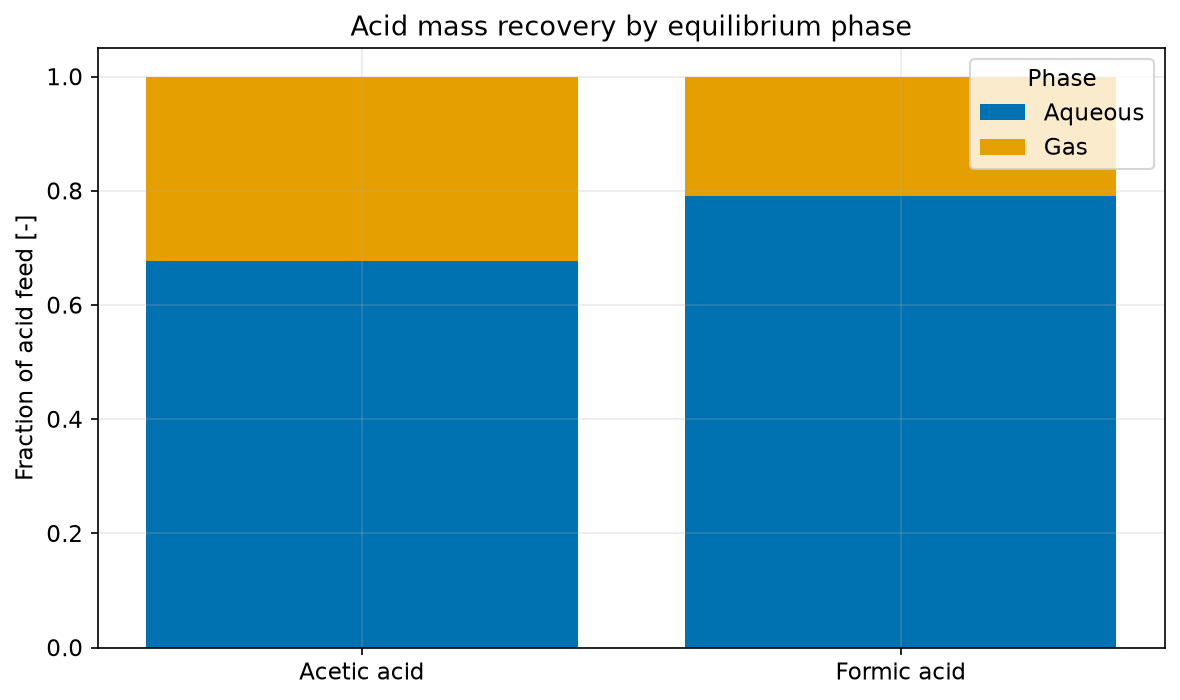

In [10]:
phase_order = ["aqueous", "gas"]
colors = {"aqueous": "#0072B2", "gas": "#E69F00"}

figure, axis = plt.subplots()
bottom = np.zeros(len(comparison_pivot))
for phase_name in phase_order:
    values = comparison_pivot.reindex(columns=phase_order)[phase_name].to_numpy()
    axis.bar(
        comparison_pivot.index,
        values,
        bottom=bottom,
        label=phase_name.capitalize(),
        color=colors[phase_name],
    )
    bottom += values

axis.set_title("Acid mass recovery by equilibrium phase")
axis.set_ylabel("Fraction of acid feed [-]")
axis.set_ylim(0.0, 1.05)
axis.legend(title="Phase")
plt.tight_layout()
plt.show()

The figure is a conservation view as well as a partition view: every bar closes at
one. Under the selected CPA screen, acetic acid has a larger gas-phase recovery than
formic acid. That trend is a model result, not a universal property guarantee.

## Temperature sensitivity

Temperature changes both phase amounts and fugacity coefficients. We rebuild the fluid
at each point from 30 to 90 °C while holding pressure and feed rates fixed. The reported
gas recovery is:

$$
R_{i,g}
=
\frac{\dot m_{i,g}}{\dot m_{i,feed}}
$$

In [11]:
temperature_rows = []
temperature_grid_c = np.arange(30.0, 91.0, 10.0)

for acid_name in ["formic acid", "acetic acid"]:
    for temperature_c in temperature_grid_c:
        _, results = run_water_gas_case(
            acid_name,
            temperature_c=temperature_c,
        )
        gas_row = results.loc[results["Phase"] == "gas"].iloc[0]
        acid_out = results["Acid mass rate [kg/h]"].sum()
        temperature_rows.append(
            {
                "Acid": acid_name.title(),
                "Temperature [°C]": temperature_c,
                "Gas acid recovery [-]": (
                    gas_row["Acid mass rate [kg/h]"] / ACID_RATE_KG_H
                ),
                "Acid residual [kg/h]": acid_out - ACID_RATE_KG_H,
            }
        )

temperature_results = pd.DataFrame(temperature_rows)
display(temperature_results.round(8))

assert temperature_results["Gas acid recovery [-]"].between(0.0, 1.0).all()
assert temperature_results["Acid residual [kg/h]"].abs().max() < 1.0e-8

,Acid,Temperature [°C],Gas acid recovery [-],Acid residual [kg/h]
0,Formic Acid,30.0,0.127862,0.0
1,Formic Acid,40.0,0.147830,0.0
2,Formic Acid,50.0,0.168148,-0.0
3,Formic Acid,60.0,0.188580,0.0
4,Formic Acid,70.0,0.208953,-0.0
5,Formic Acid,80.0,0.229170,0.0
6,Formic Acid,90.0,0.249221,0.0
7,Acetic Acid,30.0,0.211170,-0.0
8,Acetic Acid,40.0,0.240833,0.0
9,Acetic Acid,50.0,0.269707,-0.0


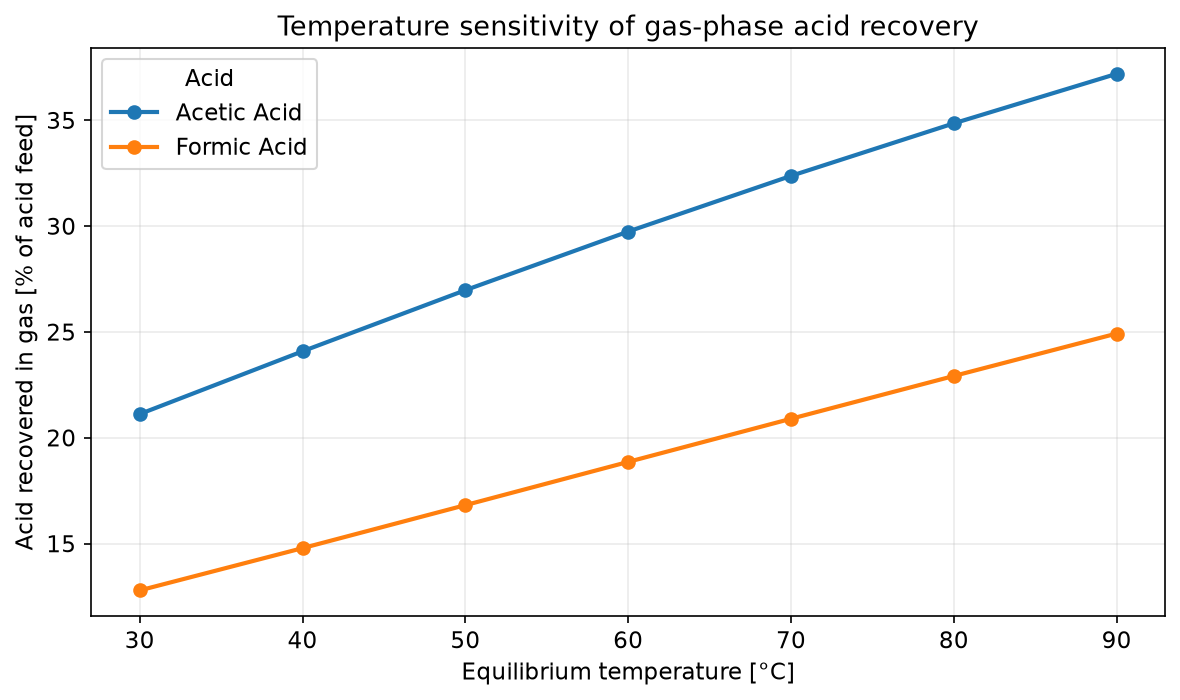

In [12]:
figure, axis = plt.subplots()
for acid_name, group in temperature_results.groupby("Acid"):
    axis.plot(
        group["Temperature [°C]"],
        100.0 * group["Gas acid recovery [-]"],
        marker="o",
        linewidth=2.0,
        label=acid_name,
    )

axis.set_title("Temperature sensitivity of gas-phase acid recovery")
axis.set_xlabel("Equilibrium temperature [°C]")
axis.set_ylabel("Acid recovered in gas [% of acid feed]")
axis.legend(title="Acid")
plt.tight_layout()
plt.show()

Both acids show a smooth temperature response over the screened interval. This is
useful for sampling and separator-temperature studies, but extrapolation outside the
validated grid should be avoided.

## Final application: three-phase produced-fluid separator

The reusable application adds n-heptane as a transparent surrogate for a light oil.
It connects a NeqSim `Stream` to a native `ThreePhaseSeparator` inside a
`ProcessSystem`, runs the flowsheet, retrieves gas, oil, and water products, and audits
both total and acid mass.

This synthetic four-component fluid is deliberately compact. A real study should replace
n-heptane with a characterized reservoir fluid and validate acid parameters against
laboratory partition data.

In [13]:
def build_three_phase_process(
    acid_name="formic acid",
    temperature_c=40.0,
    pressure_bara=25.0,
    methane_rate_kg_h=10.0,
    oil_rate_kg_h=100.0,
    acid_rate_kg_h=0.1,
    water_rate_kg_h=100.0,
):
    feed_fluid = fluid("cpa")
    feed_fluid.addComponent("methane", methane_rate_kg_h, "kg/hr")
    feed_fluid.addComponent("n-heptane", oil_rate_kg_h, "kg/hr")
    feed_fluid.addComponent(acid_name, acid_rate_kg_h, "kg/hr")
    feed_fluid.addComponent("water", water_rate_kg_h, "kg/hr")
    feed_fluid.setMixingRule(10)
    feed_fluid.setMultiPhaseCheck(True)
    feed_fluid.setTemperature(temperature_c, "C")
    feed_fluid.setPressure(pressure_bara, "bara")

    feed_stream = jneqsim.process.equipment.stream.Stream(
        "produced fluid feed",
        feed_fluid,
    )
    separator_unit = (
        jneqsim.process.equipment.separator.ThreePhaseSeparator(
            "three-phase acid separator",
            feed_stream,
        )
    )
    process_system = jneqsim.process.processmodel.ProcessSystem()
    process_system.add(feed_stream)
    process_system.add(separator_unit)
    process_system.run()

    return process_system, feed_stream, separator_unit

In [14]:
process_system, produced_feed, acid_separator = build_three_phase_process()

product_streams = {
    "gas": acid_separator.getGasOutStream(),
    "oil": acid_separator.getOilOutStream(),
    "aqueous": acid_separator.getWaterOutStream(),
}

application_rows = []
for phase_name, product_stream in product_streams.items():
    product_fluid = product_stream.getFluid()
    phase = product_fluid.getPhase(0)
    component = phase.getComponent("formic acid")
    acid_mass_fraction = (
        component.getx()
        * component.getMolarMass()
        / phase.getMolarMass()
    )
    phase_mass_rate = product_stream.getFlowRate("kg/hr")
    application_rows.append(
        {
            "Product": phase_name,
            "Mass rate [kg/h]": phase_mass_rate,
            "Formic acid [kg/h]": phase_mass_rate * acid_mass_fraction,
            "Formic acid recovery [-]": (
                phase_mass_rate * acid_mass_fraction / ACID_RATE_KG_H
            ),
        }
    )

application_results = pd.DataFrame(application_rows)
display(application_results.round(8))

,Product,Mass rate [kg/h],Formic acid [kg/h],Formic acid recovery [-]
0,gas,8.569398,0.018585,0.185852
1,oil,101.519387,0.068907,0.689071
2,aqueous,100.011214,0.012508,0.125077


In [15]:
feed_mass_rate_kg_h = produced_feed.getFlowRate("kg/hr")
product_mass_rate_kg_h = application_results["Mass rate [kg/h]"].sum()
acid_product_rate_kg_h = application_results["Formic acid [kg/h]"].sum()

process_mass_residual_kg_h = product_mass_rate_kg_h - feed_mass_rate_kg_h
process_acid_residual_kg_h = acid_product_rate_kg_h - ACID_RATE_KG_H

assert len(process_system.getUnitOperations()) == 2
assert set(application_results["Product"]) == {"gas", "oil", "aqueous"}
assert abs(process_mass_residual_kg_h) < 1.0e-8
assert abs(process_acid_residual_kg_h) < 1.0e-8

print(f"Feed mass rate: {feed_mass_rate_kg_h:.9f} kg/h")
print(f"Product mass rate: {product_mass_rate_kg_h:.9f} kg/h")
print(f"Total-mass residual: {process_mass_residual_kg_h:.3e} kg/h")
print(f"Formic-acid residual: {process_acid_residual_kg_h:.3e} kg/h")

Feed mass rate: 210.100000000 kg/h
Product mass rate: 210.100000000 kg/h
Total-mass residual: 2.120e-11 kg/h
Formic-acid residual: 1.771e-14 kg/h


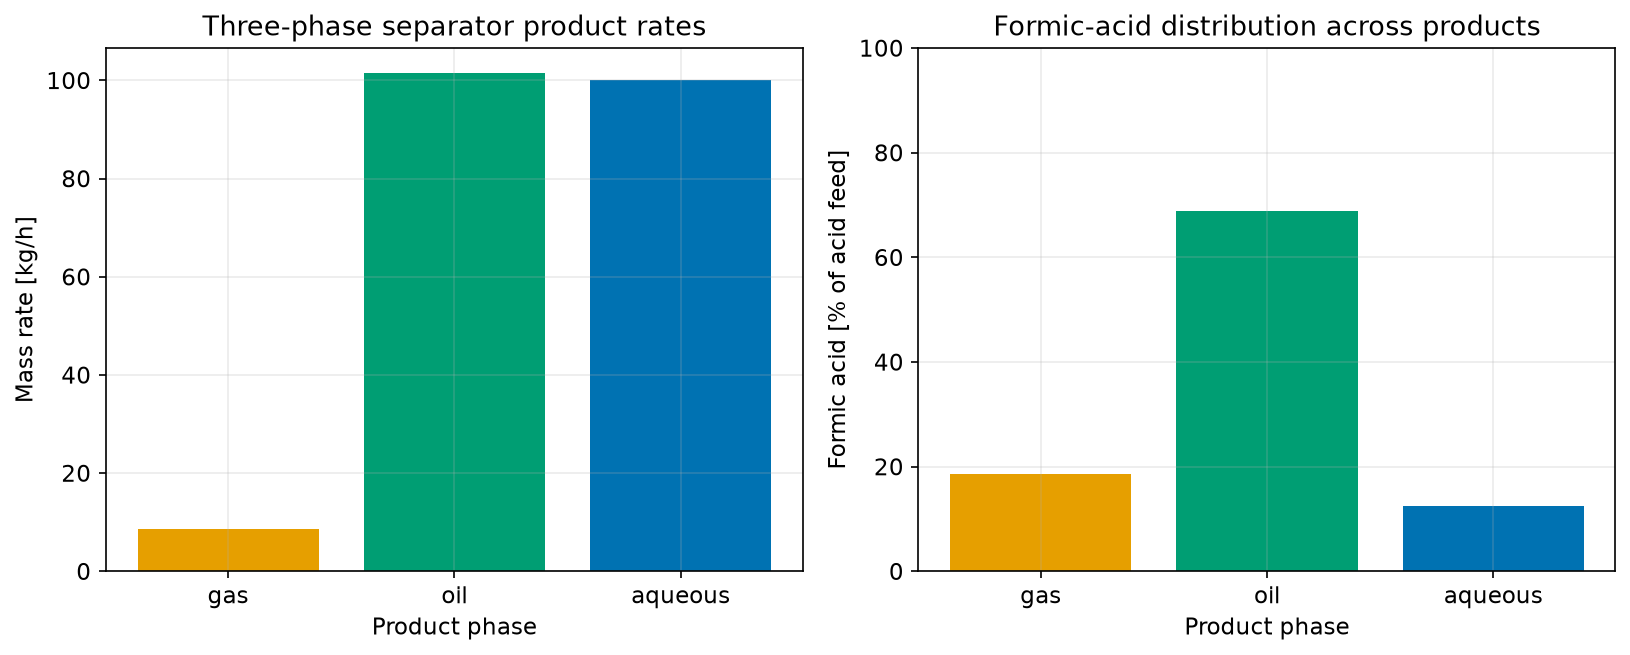

In [16]:
figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.5))

axes[0].bar(
    application_results["Product"],
    application_results["Mass rate [kg/h]"],
    color=["#E69F00", "#009E73", "#0072B2"],
)
axes[0].set_title("Three-phase separator product rates")
axes[0].set_xlabel("Product phase")
axes[0].set_ylabel("Mass rate [kg/h]")

axes[1].bar(
    application_results["Product"],
    100.0 * application_results["Formic acid recovery [-]"],
    color=["#E69F00", "#009E73", "#0072B2"],
)
axes[1].set_title("Formic-acid distribution across products")
axes[1].set_xlabel("Product phase")
axes[1].set_ylabel("Formic acid [% of acid feed]")
axes[1].set_ylim(0.0, 100.0)

plt.tight_layout()
plt.show()

The product-rate chart confirms a realistic three-product split for this synthetic
feed. The acid-distribution chart is the actionable result: it identifies which outlet
would dominate an equilibrium acid inventory under the stated model. It must be
revalidated when the oil characterization or aqueous chemistry changes.

## Water-rate design sensitivity

A five-case study varies produced-water rate while holding methane, oil, acid,
temperature, and pressure fixed. Each case builds and runs a fresh NeqSim process. This
demonstrates how the application can be reused in an operating-envelope workflow.

In [17]:
water_rate_rows = []
water_rate_grid_kg_h = np.array([25.0, 50.0, 100.0, 150.0, 200.0])

for water_rate_kg_h in water_rate_grid_kg_h:
    _, scenario_feed, scenario_separator = build_three_phase_process(
        water_rate_kg_h=water_rate_kg_h,
    )
    scenario_acid_total = 0.0
    scenario_row = {
        "Water feed [kg/h]": water_rate_kg_h,
        "Feed mass [kg/h]": scenario_feed.getFlowRate("kg/hr"),
    }

    for phase_name, stream_getter in [
        ("Gas", scenario_separator.getGasOutStream),
        ("Oil", scenario_separator.getOilOutStream),
        ("Aqueous", scenario_separator.getWaterOutStream),
    ]:
        scenario_stream = stream_getter()
        scenario_phase = scenario_stream.getFluid().getPhase(0)
        acid_component = scenario_phase.getComponent("formic acid")
        acid_mass_fraction = (
            acid_component.getx()
            * acid_component.getMolarMass()
            / scenario_phase.getMolarMass()
        )
        acid_mass_rate = (
            scenario_stream.getFlowRate("kg/hr") * acid_mass_fraction
        )
        scenario_row[f"{phase_name} acid recovery [-]"] = (
            acid_mass_rate / ACID_RATE_KG_H
        )
        scenario_acid_total += acid_mass_rate

    scenario_row["Acid residual [kg/h]"] = (
        scenario_acid_total - ACID_RATE_KG_H
    )
    water_rate_rows.append(scenario_row)

water_rate_results = pd.DataFrame(water_rate_rows)
display(water_rate_results.round(8))

assert water_rate_results["Acid residual [kg/h]"].abs().max() < 1.0e-8

,Water feed [kg/h],Feed mass [kg/h],Gas acid recovery [-],Oil acid recovery [-],Aqueous acid recovery [-],Acid residual [kg/h]
0,25.0,135.1,0.205758,0.759813,0.034429,0.0
1,50.0,160.1,0.198685,0.734673,0.066643,-0.0
2,100.0,210.1,0.185852,0.689071,0.125077,0.0
3,150.0,260.1,0.174518,0.648796,0.176686,0.0
4,200.0,310.1,0.164434,0.612967,0.222599,0.0


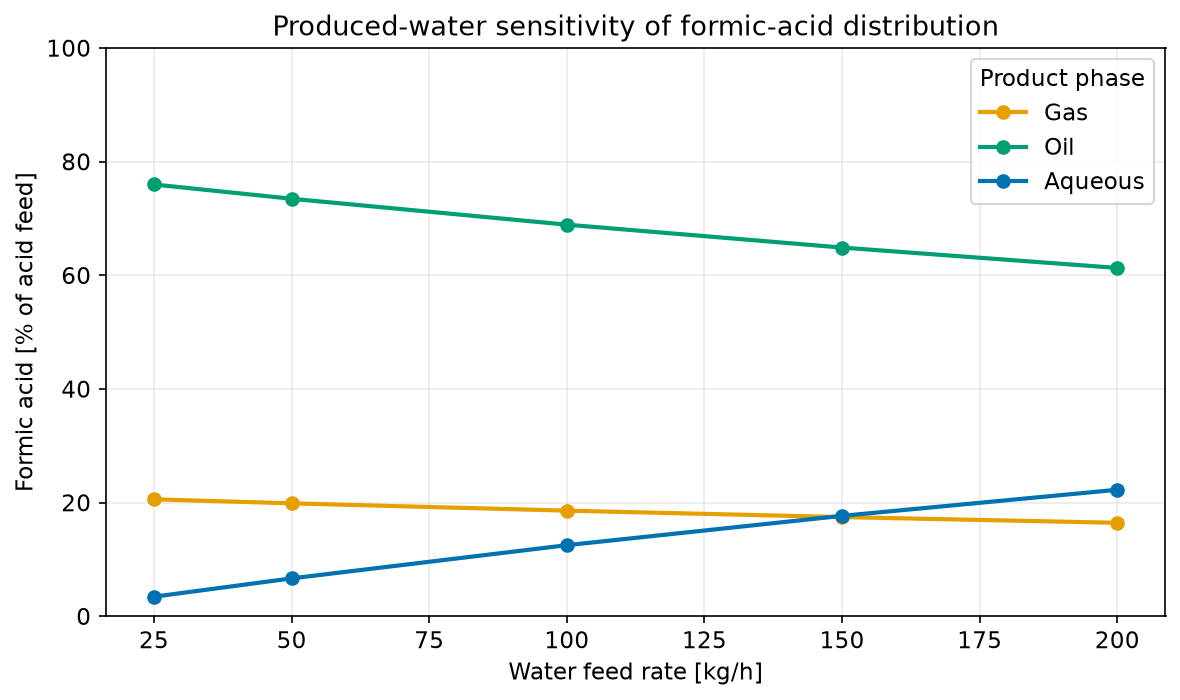

In [18]:
figure, axis = plt.subplots()
for phase_name, color in [
    ("Gas", "#E69F00"),
    ("Oil", "#009E73"),
    ("Aqueous", "#0072B2"),
]:
    axis.plot(
        water_rate_results["Water feed [kg/h]"],
        100.0 * water_rate_results[f"{phase_name} acid recovery [-]"],
        marker="o",
        linewidth=2.0,
        color=color,
        label=phase_name,
    )

axis.set_title("Produced-water sensitivity of formic-acid distribution")
axis.set_xlabel("Water feed rate [kg/h]")
axis.set_ylabel("Formic acid [% of acid feed]")
axis.set_ylim(0.0, 100.0)
axis.legend(title="Product phase")
plt.tight_layout()
plt.show()

The scenario curves show the coupled response rather than assuming a fixed
distribution coefficient. Increasing water changes phase amounts and all equilibrium
compositions. The trends are valid only for this surrogate oil and CPA parameter set.

## Final validation

The final gate checks finiteness, non-negativity, recovery closure, exact preservation of
the two original acid cases, process mass closure, scenario acid closure, and the expected
temperature-grid ordering.

In [19]:
validation_checks = {
    "formic acid closure": abs(formic_acid_residual) < 1.0e-9,
    "formic total closure": abs(formic_total_residual) < 1.0e-8,
    "acetic acid closure": (
        abs(acetic_acid_out_kg_h - ACID_RATE_KG_H) < 1.0e-9
    ),
    "original cases have gas and aqueous phases": (
        set(formic_results["Phase"]) == {"gas", "aqueous"}
        and set(acetic_results["Phase"]) == {"gas", "aqueous"}
    ),
    "base recoveries close": np.allclose(
        comparison_pivot.sum(axis=1),
        1.0,
        atol=1.0e-9,
    ),
    "temperature results finite": np.isfinite(
        temperature_results.select_dtypes(include=[np.number])
    ).all().all(),
    "temperature recoveries bounded": (
        temperature_results["Gas acid recovery [-]"].between(0.0, 1.0).all()
    ),
    "temperature grid ordered": np.array_equal(
        np.sort(temperature_results["Temperature [°C]"].unique()),
        temperature_grid_c,
    ),
    "process has two units": len(process_system.getUnitOperations()) == 2,
    "three products returned": (
        set(application_results["Product"]) == {"gas", "oil", "aqueous"}
    ),
    "process mass closure": abs(process_mass_residual_kg_h) < 1.0e-8,
    "process acid closure": abs(process_acid_residual_kg_h) < 1.0e-8,
    "product results finite": np.isfinite(
        application_results.select_dtypes(include=[np.number])
    ).all().all(),
    "product results non-negative": (
        application_results.select_dtypes(include=[np.number]) >= 0.0
    ).all().all(),
    "water scenarios close": (
        water_rate_results["Acid residual [kg/h]"].abs().max() < 1.0e-8
    ),
}

validation_table = pd.DataFrame(
    {
        "Check": list(validation_checks),
        "Passed": list(validation_checks.values()),
    }
)
display(validation_table)

assert all(validation_checks.values())
print(f"All {len(validation_checks)} engineering checks passed.")

All 15 engineering checks passed.


,Check,Passed
0,formic acid closure,True
1,formic total closure,True
2,acetic acid closure,True
3,original cases have gas and aqueous phases,True
4,base recoveries close,True
5,temperature results finite,True
6,temperature recoveries bounded,True
7,temperature grid ordered,True
8,process has two units,True
9,three products returned,True


## Troubleshooting, limitations, and applicability

- **Only one liquid phase appears:** enable multiphase checking and confirm that both
  water and hydrocarbon are present at meaningful rates.
- **A component name fails:** use NeqSim database names such as `formic acid`,
  `acetic acid`, and `n-heptane`.
- **Unexpected acid split:** first check mass closure, then examine model choice,
  temperature, pressure, oil characterization, and available binary parameters.
- **Do not interpret neutral-acid equilibrium as pH:** dissociation and electrolyte
  speciation require a validated reactive/electrolyte model and aqueous analyses.
- **Do not use this notebook as a corrosion-rate model:** metallurgy, wall temperature,
  water chemistry, flow regime, mass transfer, and protective films are outside scope.
- **Scale-up:** replace the surrogate oil, regress or validate against partition data,
  and test separator residence-time and non-equilibrium effects.

In [20]:
result_snapshot = {
    "neqsim_version": NEQSIM_VERSION,
    "base_conditions": {
        "temperature_C": BASE_TEMPERATURE_C,
        "pressure_bara": BASE_PRESSURE_BARA,
    },
    "preserved_examples": ["formic acid", "acetic acid"],
    "base_formic_gas_recovery": float(
        comparison_pivot.loc["Formic acid", "gas"]
    ),
    "base_acetic_gas_recovery": float(
        comparison_pivot.loc["Acetic acid", "gas"]
    ),
    "three_phase_mass_residual_kg_h": float(process_mass_residual_kg_h),
    "three_phase_acid_residual_kg_h": float(process_acid_residual_kg_h),
    "engineering_checks_passed": int(sum(validation_checks.values())),
}

print(json.dumps(result_snapshot, indent=2))

{
  "neqsim_version": "3.16.0",
  "base_conditions": {
    "temperature_C": 70.0,
    "pressure_bara": 25.0
  },
  "preserved_examples": [
    "formic acid",
    "acetic acid"
  ],
  "base_formic_gas_recovery": 0.2089529608038946,
  "base_acetic_gas_recovery": 0.32370753050673695,
  "three_phase_mass_residual_kg_h": 2.120259523508139e-11,
  "three_phase_acid_residual_kg_h": 1.7708057242771247e-14,
  "engineering_checks_passed": 15
}


## Summary and further exercises

Both original acid flashes now run with current NeqSim APIs and close their total and acid
balances. The expanded workflow adds mass-based phase accounting, temperature
sensitivity, a native three-phase process model, water-rate scenarios, figures, and
explicit applicability limits.

Exercises:

1. Replace n-heptane with a characterized oil and compare the acid split.
2. Sweep pressure while holding temperature fixed.
3. Compare CPA with another model only after checking component support and parameters.
4. Add laboratory partition data and quantify residuals without tuning to the validation
   points.
5. Couple the separator products to a water-treatment or corrosion-screening workflow.

References:

- [NeqSim thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim process simulation](https://equinor.github.io/neqsim/process/)
- [NeqSim separator documentation](https://equinor.github.io/neqsim/process/equipment/separators.html)
- [NeqSim Colab quick start](https://equinor.github.io/neqsim/quickstart/colab-quickstart.html)
- [NeqSim on PyPI](https://pypi.org/project/neqsim/)